# Multi-Store, Multi-Item Sales Forecasting with XGBoost and LightGBM

This notebook provides a full pipeline for daily, weekly, and monthly sales forecasting across multiple stores and items using XGBoost and LightGBM. It covers feature engineering, model training, forecasting, aggregation, evaluation, visualization, and saving outputs.

## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [38]:
!pip install xgboost
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates

# Load processed data
with open('../../data/df_processed.pkl', 'rb') as f:
    df_scoped_processed = pickle.load(f)
df = df_scoped_processed['df_processed']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_nbr', 'item_nbr', 'date'])


[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: c:\Users\jasmi\Documents\2025_Data_analyse\202501_Ames_housing\.venv\Scripts\python.exe -m pip install --upgrade pip


## 2. Feature Engineering: Lag, Rolling, Earthquake, Oil Price and Baseline Features

Create lag features, rolling mean features, and a baseline feature for each store/item using groupby and shift/rolling operations. Define FEATURES and TARGET variables.

In [39]:
#Earthquake feature engineering
df['earthquake_event'] = (df['magnitude'] > 0).astype(int)
df['days_since_earthquake'] = df['date'] - df.loc[df['earthquake_event'] == 1, 'date'].max()
df['days_since_earthquake'] = df['days_since_earthquake'].dt.days
df['days_since_earthquake'] = df['days_since_earthquake'].where(df['earthquake_event'] == 0, 0)
df['days_since_earthquake'] = df['days_since_earthquake'].clip(lower=0)

#Lag features and rolling means
LAGS = [1,7,14,28]
ROLLS = [7,14]

for lag in LAGS:
    df[f'lag_{lag}'] = df.groupby(['store_nbr','item_nbr'])['unit_sales'].shift(lag)
for roll in ROLLS:
    df[f'roll_mean_{roll}'] = df.groupby(['store_nbr','item_nbr'])['unit_sales'].shift(1).rolling(roll).mean()

# Baseline feature: average sales same period last month
df['baseline'] = df.groupby(['store_nbr','item_nbr'])['unit_sales'].shift(28).rolling(28).mean()

# Define features and target
EXTRA_FEATURES = ['days_since_earthquake', 'oil_price']  # add more if needed
FEATURES = [f'lag_{lag}' for lag in LAGS] + [f'roll_mean_{roll}' for roll in ROLLS] + ['baseline'] + EXTRA_FEATURES
TARGET = 'unit_sales'

# Drop rows with NaNs in features
df_model = df.dropna().copy()

print(df_model.index)
print(df_model.index.dtype)


Index([     89,      90,      91,      92,      93,      94,      95,      96,
            97,      98,
       ...
       1640586, 1640587, 1640588, 1640589, 1640590, 1640591, 1640592, 1640593,
       1640594, 1640595],
      dtype='int64', length=1585824)
int64


## 3. Define final validation set and training set for cross validation

In [40]:
# Ensure datetime index
df_model['date'] = pd.to_datetime(df_model['date'])
df_model = df_model.set_index('date').sort_index()

# Define hold-out test set
test_final_days = 60   # About 2 months for final test, is about equal to forecast horizon
cutoff_date = df_model.index.max() - pd.Timedelta(days=test_final_days)

df_trainval = df_model[df_model.index <= cutoff_date]
df_test_final = df_model[df_model.index > cutoff_date]

print("Train/Val data:", df_trainval.index.min().date(), "to", df_trainval.index.max().date())
print("Final Test data:", df_test_final.index.min().date(), "to", df_test_final.index.max().date())


Train/Val data: 2014-04-01 to 2017-06-16
Final Test data: 2017-06-17 to 2017-08-15


## 4. Cross validation on trainval

In [41]:
# TimeSeriesSplit on trainval data only
dates = df_trainval.index.unique()
tss = TimeSeriesSplit(n_splits=5, test_size=2*30, gap=7)  # 60-day val sets

cv_scores_lgb, cv_scores_xgb = [], []

for fold, (train_idx, val_idx) in enumerate(tss.split(dates)):
    train_dates = dates[train_idx]
    val_dates   = dates[val_idx]

    train = df_trainval[df_trainval.index.isin(train_dates)]
    val   = df_trainval[df_trainval.index.isin(val_dates)]

    X_train, y_train = train[FEATURES], np.log1p(train[TARGET])
    X_val, y_val     = val[FEATURES], np.log1p(val[TARGET])

    # ----- LightGBM -----
    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

    params_lgb = {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05,
    'num_leaves': 31, 'verbose': -1}

    model_lgb = lgb.train(params_lgb, lgb_train, valid_sets=[lgb_val],
                          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

    val_pred = model_lgb.predict(X_val, num_iteration=model_lgb.best_iteration)
    rmse_lgb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred)))
    mae_lgb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred))
    cv_scores_lgb.append((rmse_lgb, mae_lgb))

    # ----- XGBoost -----
    xgb_train = xgb.DMatrix(X_train, label=y_train)
    xgb_val = xgb.DMatrix(X_val, label=y_val)

    # XGBoost parameters
    params_xgb = {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'learning_rate': 0.05,
    'max_depth': 6, 'verbosity': 0}

    model_xgb = xgb.train(params_xgb, xgb_train,
                          evals=[(xgb_val, 'val')],
                          early_stopping_rounds=50, verbose_eval=False)

    val_pred = model_xgb.predict(xgb_val, iteration_range=(0, model_xgb.best_iteration))
    rmse_xgb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred)))
    mae_xgb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred))
    cv_scores_xgb.append((rmse_xgb, mae_xgb))

    print(f"Fold {fold+1}: LGB RMSE={rmse_lgb:.3f}, MAE={mae_lgb:.3f} | "
          f"XGB RMSE={rmse_xgb:.3f}, MAE={mae_xgb:.3f}")

print("Average LGB RMSE:", np.mean([x[0] for x in cv_scores_lgb]))
print("Average LGB MAE:",  np.mean([x[1] for x in cv_scores_lgb]))
print("Average XGB RMSE:", np.mean([x[0] for x in cv_scores_xgb]))
print("Average XGB MAE:",  np.mean([x[1] for x in cv_scores_xgb]))


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's rmse: 0.474363
Fold 1: LGB RMSE=6.230, MAE=3.764 | XGB RMSE=11.236, MAE=5.711
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 0.5027
Fold 2: LGB RMSE=8.706, MAE=4.122 | XGB RMSE=12.992, MAE=6.026
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 0.521008
Fold 3: LGB RMSE=9.027, MAE=4.614 | XGB RMSE=13.337, MAE=6.410
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[83]	valid_0's rmse: 0.505981
Fold 4: LGB RMSE=7.843, MAE=4.299 | XGB RMSE=12.693, MAE=6.207
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 0.502871
Fold 5: LGB RMSE=7.198, MAE=4.110 | XGB RMSE=11.653,

## 5. Plot showing training/val set together with final test set

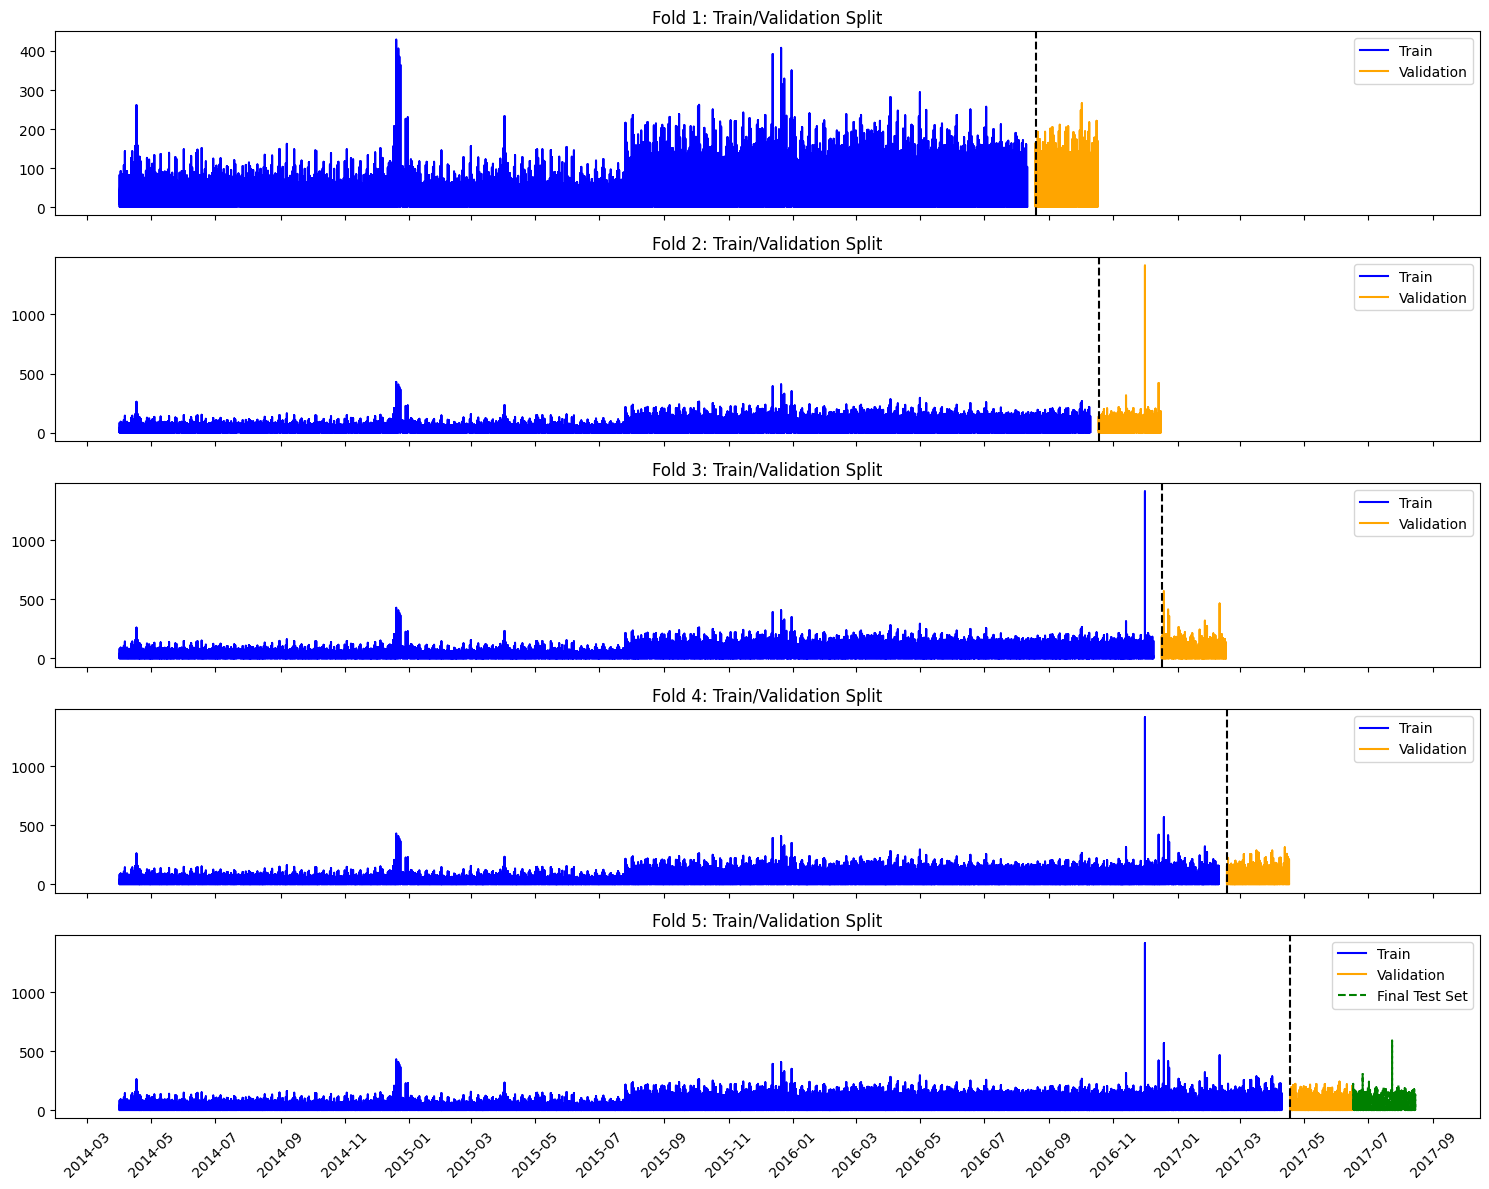

In [43]:
# Plot setup
fig, axs = plt.subplots(tss.n_splits, 1, figsize=(15, 12), sharex=True)

for fold, (train_idx, val_idx) in enumerate(tss.split(dates)):
    train_dates = dates[train_idx]
    val_dates   = dates[val_idx]

    train = df_trainval[df_trainval.index.isin(train_dates)]
    val   = df_trainval[df_trainval.index.isin(val_dates)]

    axs[fold].plot(train.index, train['unit_sales'], label='Train', color='blue')
    axs[fold].plot(val.index, val['unit_sales'], label='Validation', color='orange')

    # Vertical line at validation start
    axs[fold].axvline(val.index.min(), color='black', linestyle='--')
    axs[fold].set_title(f'Fold {fold+1}: Train/Validation Split')
    axs[fold].legend()

# Plot the final test set on the last fold for context
axs[-1].plot(df_test_final.index, df_test_final['unit_sales'], 
             label='Final Test Set', color='green', linestyle='--')
axs[-1].legend()

# Format x-axis nicely
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


for ax in axs:
    # Choose tick frequency (e.g., one tick per month)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)  # rotate labels for readability


plt.tight_layout()
plt.show()

## 6. Train on full trainval and validate on final test data

In [28]:
# Pick one model (say LightGBM after tuning)
X_trainval, y_trainval = df_trainval[FEATURES], np.log1p(df_trainval[TARGET])
X_test, y_test = df_test_final[FEATURES], np.log1p(df_test_final[TARGET])

# Train on all trainval data
lgb_train = lgb.Dataset(X_trainval, label=y_trainval)
final_model = lgb.train(params_lgb, lgb_train)

# Evaluate on final hold-out test
y_pred = final_model.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
mae_final = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print("Final Test RMSE:", rmse_final)
print("Final Test MAE:", mae_final)


Final Test RMSE: 6.071796705773034
Final Test MAE: 3.552797772978768


## 3. Prepare Train/Test Split

Split the data into training and test sets based on a cutoff date. 

Fold 1: Train from 2014-04-01 to 2016-10-30, Test from 2016-11-07 to 2017-01-03, Train size: 1170296, Test size: 82826
Fold 2: Train from 2014-04-01 to 2016-12-26, Test from 2017-01-04 to 2017-02-28, Train size: 1253423, Test size: 82382
Fold 3: Train from 2014-04-01 to 2017-02-21, Test from 2017-03-01 to 2017-04-25, Train size: 1335865, Test size: 81732
Fold 4: Train from 2014-04-01 to 2017-04-18, Test from 2017-04-26 to 2017-06-20, Train size: 1417599, Test size: 79645
Fold 5: Train from 2014-04-01 to 2017-06-13, Test from 2017-06-21 to 2017-08-15, Train size: 1497786, Test size: 78278


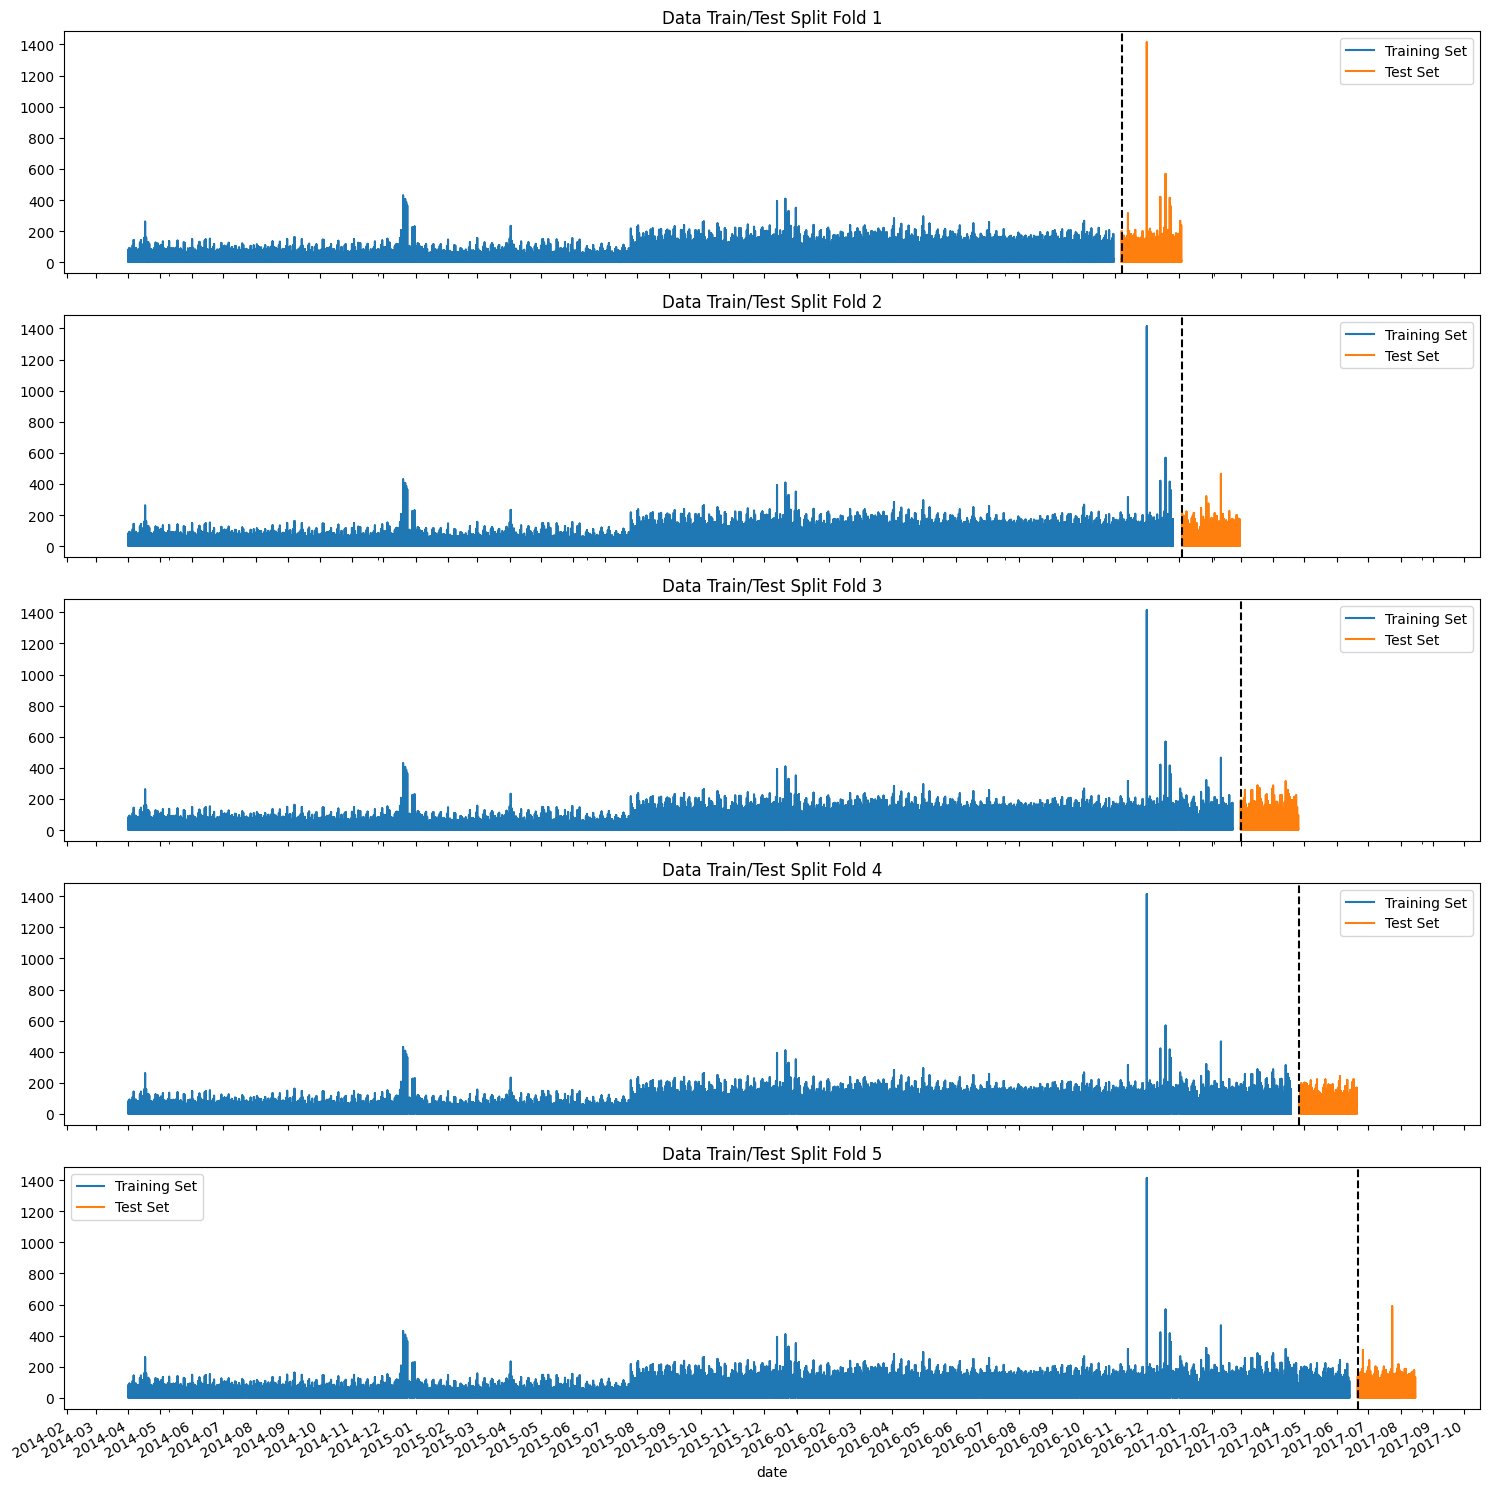

In [16]:
df_model['date'] = pd.to_datetime(df_model['date'])   # ensure datetime type
df_model = df_model.set_index('date').sort_index()


# TimeSeriesSplit setup
dates = df_model.index.unique()
tss = TimeSeriesSplit(n_splits=5, test_size=2*28, gap=7)  # 56 days, for example

for fold, (train_idx, val_idx) in enumerate(tss.split(dates)):
    train_dates = dates[train_idx]
    test_dates = dates[val_idx]

    train = df_model[df_model.index.isin(train_dates)]
    test = df_model[df_model.index.isin(test_dates)]

# Optional: drop item-stores with no training history
    seen_ids = train[["item_nbr","store_nbr"]].drop_duplicates()
    test = test.reset_index().merge(seen_ids, on=["item_nbr","store_nbr"], how="inner")
    test = test.set_index("date").sort_index()
    print(f"Fold {fold+1}: Train from {train.index.min().date()} to {train.index.max().date()}, "
          f"Test from {test.index.min().date()} to {test.index.max().date()}, "
          f"Train size: {len(train)}, Test size: {len(test)}")

# Setup figure
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

for fold, (train_idx, val_idx) in enumerate(tss.split(dates)):
    train_dates = dates[train_idx]
    test_dates = dates[val_idx]

    train = df_model[df_model.index.isin(train_dates)]
    test = df_model[df_model.index.isin(test_dates)]

    train['unit_sales'].plot(ax=axs[fold],
                             label='Training Set',
                             title=f'Data Train/Test Split Fold {fold+1}')
    test['unit_sales'].plot(ax=axs[fold],
                            label='Test Set')

    # vertical line at split
    axs[fold].axvline(test.index.min(), color='black', ls='--')

    # format x-axis as dates
    axs[fold].xaxis.set_major_locator(mdates.MonthLocator())
    axs[fold].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axs[fold].legend()

plt.tight_layout()
plt.show()





## 4. Train XGBoost and LightGBM Models

Train XGBoost and LightGBM regression models on the training data using log-transformed targets.

In [ ]:
cv_scores_lgb, cv_scores_xgb = [], []

# LightGBM parameters
params_lgb = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1}

# XGBoost parameters
params_xgb = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'verbosity': 0}

for fold, (train_idx, val_idx) in enumerate(tss.split(df_model)):
    train, val = df_model.iloc[train_idx], df_model.iloc[val_idx]
    
    X_train, y_train = train[FEATURES], np.log1p(train[TARGET])
    X_val, y_val = val[FEATURES], np.log1p(val[TARGET])

    # ----- LightGBM -----
    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

    model_lgb = lgb.train(params_lgb, lgb_train, valid_sets=[lgb_val],
                          callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)])

    val_pred_lgb = model_lgb.predict(X_val, num_iteration=model_lgb.best_iteration)
    rmse_lgb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred_lgb)))
    mae_lgb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred_lgb))
    cv_scores_lgb.append((rmse_lgb, mae_lgb))

    # ----- XGBoost -----
    xgb_train = xgb.DMatrix(X_train, label=y_train)
    xgb_val = xgb.DMatrix(X_val, label=y_val)

    model_xgb = xgb.train(params_xgb, xgb_train,
                          evals=[(xgb_val, 'val')],
                          early_stopping_rounds=50, verbose_eval=False)

    val_pred_xgb = model_xgb.predict(xgb_val, iteration_range=(0, model_xgb.best_iteration))
    rmse_xgb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred_xgb)))
    mae_xgb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred_xgb))
    cv_scores_xgb.append((rmse_xgb, mae_xgb))
    print(f"Fold {fold+1}: LGB RMSE={rmse_lgb:.3f}, XGB RMSE={rmse_xgb:.3f}")
    print(f"Fold {fold+1}: MAE RMSE={mae_lgb:.3f},  MAE RMSE={mae_xgb:.3f}")


lgb_rmse = [x[0] for x in cv_scores_lgb]
lgb_mae = [x[1] for x in cv_scores_lgb]

print("Average LGB RMSE:", np.mean(lgb_rmse))
print("Average LGB MAE:", np.mean(lgb_mae))

xgb_rmse = [x[0] for x in cv_scores_xgb]
xgb_mae = [x[1] for x in cv_scores_xgb]
print("Average XGB RMSE:", np.mean(xgb_rmse))
print("Average XGB MAE:", np.mean(xgb_mae))

## 5.1 Daily 7-Day Forecast per Store/Item - Light GBM

For each store/item, generate a 7-day daily forecast using the trained models, updating lag/rolling features iteratively.

In [ ]:
# Define horizon for evaluation
future_horizon = 60
last_date = df_model['date'].max()
stores_items = df_model.groupby(['store_nbr', 'item_nbr']).tail(1)[['store_nbr', 'item_nbr']]

rows = []
for _, row in stores_items.iterrows():
    store = row['store_nbr']
    item = row['item_nbr']
    history = df_model[(df_model['store_nbr'] == store) & (df_model['item_nbr'] == item)]['unit_sales'].values
    if len(history) < max(max(LAGS), max(ROLLS), 28):
        continue  # skip if not enough history
    for day in range(1, future_horizon + 1):
        future_date = last_date + pd.Timedelta(days=day)
        X_pred = {}
        for lag in LAGS:
            X_pred[f'lag_{lag}'] = history[-lag]
        for roll in ROLLS:
            X_pred[f'roll_mean_{roll}'] = history[-roll:].mean()
        X_pred['baseline'] = history[-28:].mean()
        # --- Add extra features for the forecast date ---
        X_pred['days_since_earthquake'] = 0.0  # or your computed value
        X_pred['oil_price'] = 0.0  # or your estimated value
        # If you add more features, set them here

        # Ensure all features are present and in correct order
        for feat in FEATURES:
            if feat not in X_pred:
                X_pred[feat] = 0.0  # or a sensible default

        X_pred_df = pd.DataFrame([X_pred])[FEATURES]
        pred_lgb = np.expm1(lgb_model.predict(X_pred_df))[0]
        pred_base = X_pred['baseline']
        rows.append({
            'store_nbr': store,
            'item_nbr': item,
            'date': future_date,
            'pred_lgb': pred_lgb,
            'pred_baseline': pred_base
        })
        history = np.append(history, pred_lgb)

daily_forecast_lgb = pd.DataFrame(rows)
display(daily_forecast_lgb.head(21))

## 5.2 Daily 7-Day Forecast per Store/Item - XGBoost

For each store/item, generate a 7-day daily forecast using the trained models, updating lag/rolling features iteratively.

In [ ]:
# Define horizon for evaluation
future_horizon = 60
last_date = df_model['date'].max()
stores_items = df_model.groupby(['store_nbr', 'item_nbr']).tail(1)[['store_nbr', 'item_nbr']]

rows = []
for _, row in stores_items.iterrows():
    store = row['store_nbr']
    item = row['item_nbr']
    history = df_model[(df_model['store_nbr'] == store) & (df_model['item_nbr'] == item)]['unit_sales'].values
    if len(history) < max(max(LAGS), max(ROLLS), 28):
        continue  # skip if not enough history
    for day in range(1, future_horizon + 1):
        future_date = last_date + pd.Timedelta(days=day)
        X_pred = {}
        for lag in LAGS:
            X_pred[f'lag_{lag}'] = history[-lag]
        for roll in ROLLS:
            X_pred[f'roll_mean_{roll}'] = history[-roll:].mean()
        X_pred['baseline'] = history[-28:].mean()
        # --- Add extra features for the forecast date ---
        X_pred['days_since_earthquake'] = 0.0  # or your computed value
        X_pred['oil_price'] = 0.0  # or your estimated value
        # If you add more features, set them here

        # Ensure all features are present and in correct order
        for feat in FEATURES:
            if feat not in X_pred:
                X_pred[feat] = 0.0  # or a sensible default

        X_pred_df = pd.DataFrame([X_pred])[FEATURES]
        pred_xgb = np.expm1(xgb_model.predict(xgb.DMatrix(X_pred_df)))[0]
        pred_base = X_pred['baseline']
        rows.append({
            'store_nbr': store,
            'item_nbr': item,
            'date': future_date,
            'pred_xgb': pred_xgb,
            'pred_baseline': pred_base
        })
        history = np.append(history, pred_xgb)

daily_forecast_xgb = pd.DataFrame(rows)
display(daily_forecast_xgb.head(21))

## 6.1 Aggregate Weekly and Monthly Forecasts - LGB

Aggregate the daily forecasts to weekly and monthly totals for higher-level reporting.

In [ ]:
# 1. Make sure your daily_forecast_lgb covers at least the next 60 days
# (Set future_horizon = 60 or more when generating daily_forecast_lgb)

# 2. Filter for the next 2 weeks and 2 months
today = daily_forecast_lgb['date'].min()
end_2weeks = today + pd.Timedelta(days=13)
end_2months = today + pd.DateOffset(months=2) - pd.Timedelta(days=1)

# Next 2 weeks forecast (for warehouse)
df_2weeks = daily_forecast_lgb[(daily_forecast_lgb['date'] >= today) & (daily_forecast_lgb['date'] <= end_2weeks)].copy()
df_2weeks['week'] = df_2weeks['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_forecast_2weeks_lgb = df_2weeks.groupby(['store_nbr', 'week'])[['pred_lgb']].sum().reset_index()

# Next 2 months forecast (for procurement)
df_2months = daily_forecast_lgb[(daily_forecast_lgb['date'] >= today) & (daily_forecast_lgb['date'] <= end_2months)].copy()
df_2months['month'] = df_2months['date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_forecast_2months_lgb = df_2months.groupby(['item_nbr', 'month'])[['pred_lgb']].sum().reset_index()

## 6.2 Aggregate Weekly and Monthly Forecasts - XGB

Aggregate the daily forecasts to weekly and monthly totals for higher-level reporting.

In [ ]:
# 1. Make sure your daily_forecast_xgb covers at least the next 60 days
# (Set future_horizon = 60 or more when generating daily_forecast_xgb)

# 2. Filter for the next 2 weeks and 2 months
today = daily_forecast_xgb['date'].min()
end_2weeks = today + pd.Timedelta(days=13)
end_2months = today + pd.DateOffset(months=2) - pd.Timedelta(days=1)

# Next 2 weeks forecast (for warehouse)
df_2weeks = daily_forecast_xgb[(daily_forecast_xgb['date'] >= today) & (daily_forecast_xgb['date'] <= end_2weeks)].copy()
df_2weeks['week'] = df_2weeks['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_forecast_2weeks_xgb = df_2weeks.groupby(['store_nbr', 'week'])[['pred_xgb']].sum().reset_index()

# Next 2 months forecast (for procurement)
df_2months = daily_forecast_xgb[(daily_forecast_xgb['date'] >= today) & (daily_forecast_xgb['date'] <= end_2months)].copy()
df_2months['month'] = df_2months['date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_forecast_2months_xgb = df_2months.groupby(['item_nbr', 'month'])[['pred_xgb']].sum().reset_index()

## 7 Compute and Display DAILY / WEEKLY/ MONTHLY Metrics - BASELINE, LGB, XGB

Define and compute evaluation metrics (RMSE, MAE, MAPE, Asymmetric WMAE) comparing forecasts to actuals.

In [ ]:
def asym_wmae(y_true, y_pred, alpha=0.333, wi=1.25):
    """
    Compute Asymmetrical Weighted MAE with perishable weight.
    alpha: penalty for under-forecasting (0.5 = symmetric)
    wi: perishable weight (use 1.25 for all if only perishables)
    """
    errors = y_true - y_pred
    weights = np.where(errors > 0, alpha, 1 - alpha)
    wmae = np.sum(wi * weights * np.abs(errors)) / np.sum(wi * weights)
    return wmae

def compute_metrics(y_true, y_pred, alpha=0.333, wi=1.25):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))) * 100
    asym_wmae_score = asym_wmae(y_true, y_pred, alpha=alpha, wi=wi)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Asym_WMAE': asym_wmae_score}

# Predict on test set (vectorized, fast)
test['pred_lgb'] = np.expm1(lgb_model.predict(X_test))
test['pred_xgb'] = np.expm1(xgb_model.predict(xgb.DMatrix(X_test)))
test['pred_baseline'] = test['baseline']


# 2. Weekly metrics (per store, per week: sum items)
test_weekly = test.copy()
test_weekly['week'] = test_weekly['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_agg = test_weekly.groupby(['store_nbr', 'week'])[[TARGET, 'pred_lgb', 'pred_xgb','pred_baseline']].sum().reset_index()

metrics_weekly_lgb = compute_metrics(weekly_agg[TARGET], weekly_agg['pred_lgb'])
metrics_weekly_xgb = compute_metrics(weekly_agg[TARGET], weekly_agg['pred_xgb'])
metrics_weekly_baseline = compute_metrics(weekly_agg[TARGET], weekly_agg['pred_baseline'])

# 3. Monthly metrics (per item, per month: sum stores)
test_weekly['month'] = test_weekly['date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_agg = test_weekly.groupby(['item_nbr', 'month'])[[TARGET, 'pred_lgb','pred_xgb','pred_baseline']].sum().reset_index()

metrics_monthly_lgb = compute_metrics(monthly_agg[TARGET], monthly_agg['pred_lgb'])
metrics_monthly_xgb = compute_metrics(monthly_agg[TARGET], monthly_agg['pred_xgb'])
metrics_monthly_baseline = compute_metrics(monthly_agg[TARGET], monthly_agg['pred_baseline'])

# 4. Show all metrics in a table
metrics_all = pd.DataFrame(
    [
        compute_metrics(test[TARGET], test['pred_lgb']),
        compute_metrics(test[TARGET], test['pred_xgb']),
        compute_metrics(test[TARGET], test['pred_baseline']),
        metrics_weekly_lgb,
        metrics_weekly_xgb,
        metrics_weekly_baseline,
        metrics_monthly_lgb,
        metrics_monthly_xgb,
        metrics_monthly_baseline
    ],
    index=[
        'Daily_LightGBM', 'Daily_XGBoost', 'Daily_Baseline',
        'Weekly_LightGBM', 'Weekly_XGBoost','Weekly_Baseline',
        'Monthly_LightGBM', 'Monthly_XGBoost','Monthly_Baseline'
    ]
)
display(metrics_all)

## 8. Plot Forecasts - BASELINE, LGB, XGB


Plot total daily, weekly, and monthly forecasts using matplotlib for visual inspection.

In [ ]:
def plot_forecast(df_forecast, date_col='date', value_col='pred_lgb', title='Forecast'):
    plt.figure(figsize=(12, 5))
    plt.plot(df_forecast[date_col], df_forecast[value_col], marker='o')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# Plot total daily forecast
plot_forecast(daily_forecast_lgb.groupby('date')['pred_lgb'].sum().reset_index(), title='Total Daily Forecast (sum all stores/items)')

# Plot weekly forecast
plot_forecast(weekly_forecast_2weeks_lgb, date_col='week', title='Weekly Forecast (per store)')

# Plot monthly forecast
plot_forecast(monthly_forecast_2months_lgb, date_col='month', title='Monthly Forecast (per item)')

## 8.2 Plot Daily Total Sales + Forecasts - BASELINE, LGB, XGB

In [ ]:
# Plot total sales: actuals (train/test), test predictions, and forecast

train_total = train.groupby('date')['unit_sales'].sum().reset_index()
test_total = test.groupby('date')[['unit_sales', 'pred_lgb']].sum().reset_index()
forecast_total = daily_forecast_lgb.groupby('date')['pred_lgb'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(train_total['date'], train_total['unit_sales'], label='Train Actual', color='blue')
plt.plot(test_total['date'], test_total['unit_sales'], label='Test Actual', color='green')
plt.plot(test_total['date'], test_total['pred_lgb'], label='Test Prediction (LGB)', color='orange')
plt.plot(forecast_total['date'], forecast_total['pred_lgb'], label='7-Day Forecast (LGB)', color='red', marker='o')

plt.title('Total Sales: Actuals, Predictions, and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 8.3 Plot Daily Total Sales + Forecasts for an ITEM/STORE combination - BASELINE, LGB, XGB

In [ ]:
# Plot actuals and predictions for train, test, and forecast for a single store/item

store_id = 44
item_id = 1971328

# Get data for this store/item
df_train = train[(train['store_nbr'] == store_id) & (train['item_nbr'] == item_id)].copy()
df_test = test[(test['store_nbr'] == store_id) & (test['item_nbr'] == item_id)].copy()
df_forecast_lgb = daily_forecast_lgb[(daily_forecast_lgb['store_nbr'] == store_id) & (daily_forecast_lgb['item_nbr'] == item_id)].copy()

plt.figure(figsize=(14, 6))
plt.plot(df_train['date'], df_train['unit_sales'], label='Train Actual', color='blue')
plt.plot(df_test['date'], df_test['unit_sales'], label='Test Actual', color='green')
plt.plot(df_test['date'], df_test['pred_lgb'], label='Test Prediction (LGB)', color='orange')
plt.plot(df_forecast_lgb['date'], df_forecast_lgb['pred_lgb'], label='7-Day Forecast (LGB)', color='red', marker='o')

plt.title(f'Store {store_id}, Item {item_id}: Actuals, Predictions, and Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 9. Save Forecast Outputs

Save the daily, weekly, and monthly forecast DataFrames to CSV files for downstream use.

In [ ]:
daily_forecast_lgb.to_csv('../data/daily_forecast_lgb.csv', index=False)
weekly_forecast_2weeks_lgb.to_csv('../data/weekly_forecast_lgb.csv', index=False)
monthly_forecast_2months_lgb.to_csv('../data/monthly_forecast_lgb.csv', index=False)

daily_forecast_xgb.to_csv('../data/daily_forecast_xgb.csv', index=False)
weekly_forecast_2weeks_xgb.to_csv('../data/weekly_forecast_xgb.csv', index=False)
monthly_forecast_2months_xgb.to_csv('../data/monthly_forecast_xgb.csv', index=False)
